# P679 - Hourly Energy Consumption Forecast

## PJM Hourly Energy Consumption Analysis and Forecasting

### Submitted By:
Name- Gajender Singh


## Business Objective

PJM Interconnection LLC (PJM) is a regional transmission organization responsible for managing electricity transmission across multiple states in the United States.

The objective of this project is to analyze historical hourly electricity consumption data, identify energy consumption patterns, understand seasonal and holiday-related trends, and build forecasting models to predict future electricity demand.

The insights generated from this project can support efficient energy planning and resource allocation.

## Import Libraries

This section imports all required libraries for data analysis, visualization, and time-series forecasting.

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

### Why These Libraries?

- Pandas is used for data loading and manipulation.
- NumPy is used for numerical calculations.
- Matplotlib and Seaborn are used for data visualization.
- Warnings are suppressed to improve notebook readability.

## Load Dataset

The PJM hourly electricity consumption dataset is loaded into a Pandas DataFrame for analysis.

In [25]:
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (143206, 2)


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


### Observation

The dataset contains hourly electricity demand records and will be used for exploratory analysis and forecasting.

## Dataset Understanding

Before analysis, it is important to understand the structure and characteristics of the dataset.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [29]:
df.describe()

,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


In [31]:
print(df.columns.tolist())

['Datetime', 'PJMW_MW']


### Observation

The dataset contains a datetime column representing timestamps and an energy consumption column measured in megawatts (MW).

## Datetime Conversion

Time-series analysis requires the date column to be converted into datetime format.

In [33]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df.reset_index(drop=True, inplace=True)

In [35]:
print("Start Date:", df['Datetime'].min())
print("End Date:", df['Datetime'].max())

Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


### Observation

The dataset spans multiple years, making it suitable for identifying long-term trends and seasonal patterns.

## Missing Values Analysis

Checking for missing values is important because incomplete data can reduce forecasting accuracy.

In [37]:
df.isnull().sum()

Datetime     0
PJMW_MW      0
IsHoliday    0
dtype: int64

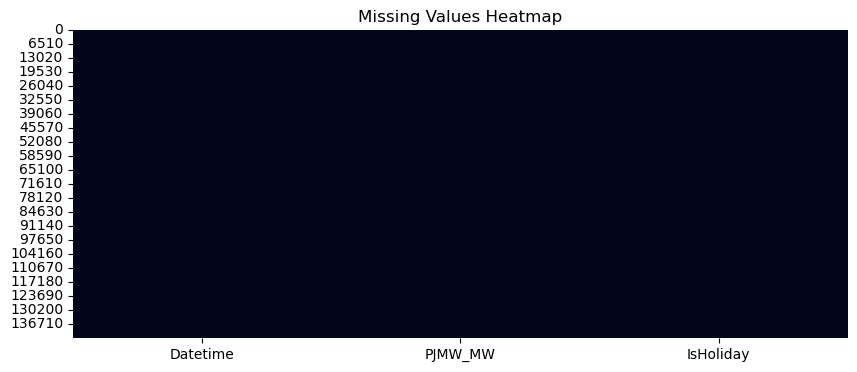

In [39]:
plt.figure(figsize=(10,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [41]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values
})

missing_df

,Column,Missing Values
0,Datetime,0
1,PJMW_MW,0
2,IsHoliday,0


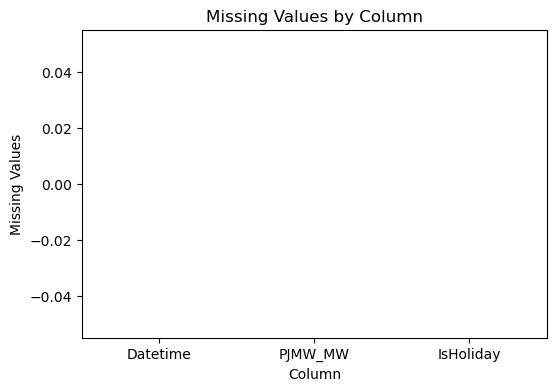

In [43]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Column',
    y='Missing Values',
    data=missing_df
)

plt.title('Missing Values by Column')

plt.show()

### Observation

No missing values were found in the dataset.

This indicates that the dataset is complete and does not require any missing value treatment before analysis and forecasting.

## Duplicate Records Check

Duplicate records can distort demand patterns and affect forecasting performance.

In [45]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


## Missing Timestamp Analysis

Time-series forecasting assumes continuity in time. Missing timestamps may introduce gaps in the analysis.

In [47]:
expected_range = pd.date_range(
    start=df['Datetime'].min(),
    end=df['Datetime'].max(),
    freq='H'
)

missing_timestamps = expected_range.difference(df['Datetime'])

print("Missing Timestamps:", len(missing_timestamps))

Missing Timestamps: 30


In [49]:
print(missing_timestamps[:30])

DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00',
               '2011-11-06 02:00:00', '2012-03-11 03:00:00',
               '2012-11-04 02:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2015-03-08 03:00:00', '2016-03-13 03:00:00',
               '2017-03-12 03:00:00', '2018-03-11 03:00:00'],
              dtype='datetime64[ns]', freq=None)


### Observation

The timestamp continuity check identified 30 missing hourly timestamps within the dataset.

Although the number of missing timestamps is very small compared to the total number of observations (143,206 records), this indicates minor gaps in the historical time series.

These gaps will be considered during the forecasting phase to ensure model reliability.

#  Feature Engineering

Feature engineering is the process of creating new variables from existing data.

These variables help us understand time-based patterns and improve forecasting performance.

In [51]:
df['Hour'] = df['Datetime'].dt.hour

df['Day'] = df['Datetime'].dt.day

df['Month'] = df['Datetime'].dt.month

df['Year'] = df['Datetime'].dt.year

df['Quarter'] = df['Datetime'].dt.quarter

df['DayOfWeek'] = df['Datetime'].dt.day_name()

In [53]:
df[['Datetime',
    'Hour',
    'Day',
    'Month',
    'Quarter',
    'Year',
    'DayOfWeek']].head()

,Datetime,Hour,Day,Month,Quarter,Year,DayOfWeek
0,2002-04-01 01:00:00,1,1,4,2,2002,Monday
1,2002-04-01 02:00:00,2,1,4,2,2002,Monday
2,2002-04-01 03:00:00,3,1,4,2,2002,Monday
3,2002-04-01 04:00:00,4,1,4,2,2002,Monday
4,2002-04-01 05:00:00,5,1,4,2,2002,Monday


In [55]:
print(df['Year'].min())
print(df['Year'].max())

2002
2018


### Observation

New time-based features were created from the Datetime column.

These features will be used to analyze electricity demand patterns across hours, days, months, quarters, and years.

## Weekend Feature

Electricity demand often differs between weekdays and weekends.

This feature helps compare consumption patterns between working days and non-working days.

In [57]:
df['IsWeekend'] = np.where(
    df['Datetime'].dt.dayofweek >= 5,
    1,
    0
)

In [59]:
df[['Datetime',
    'DayOfWeek',
    'IsWeekend']].head(10)

,Datetime,DayOfWeek,IsWeekend
0,2002-04-01 01:00:00,Monday,0
1,2002-04-01 02:00:00,Monday,0
2,2002-04-01 03:00:00,Monday,0
3,2002-04-01 04:00:00,Monday,0
4,2002-04-01 05:00:00,Monday,0
5,2002-04-01 06:00:00,Monday,0
6,2002-04-01 07:00:00,Monday,0
7,2002-04-01 08:00:00,Monday,0
8,2002-04-01 09:00:00,Monday,0
9,2002-04-01 10:00:00,Monday,0


### Observation

A new binary feature called IsWeekend was created.

0 = Weekday

1 = Weekend

In [61]:
df['DayOfWeek'].value_counts()

DayOfWeek
Tuesday      20472
Wednesday    20472
Thursday     20472
Monday       20471
Friday       20448
Saturday     20448
Sunday       20423
Name: count, dtype: int64

### Observation

The dataset contains records for all seven days of the week.

The distribution of observations across weekdays and weekends is relatively balanced, indicating that the dataset provides sufficient coverage for analyzing weekly electricity demand patterns.

## Season Feature

Seasonal weather changes significantly influence electricity demand.

This feature helps compare Winter, Spring, Summer and Autumn consumption patterns.

In [63]:
def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Autumn'


df['Season'] = df['Month'].apply(get_season)

In [65]:
df[['Month',
    'Season']].head(20)

,Month,Season
0,4,Spring
1,4,Spring
2,4,Spring
3,4,Spring
4,4,Spring
5,4,Spring
6,4,Spring
7,4,Spring
8,4,Spring
9,4,Spring


In [67]:
df['Season'].value_counts()

Season
Summer    36841
Spring    36774
Autumn    34936
Winter    34655
Name: count, dtype: int64

### Observation

Each record was assigned to a season based on its month.

This feature will be used to compare Summer and Winter demand trends as required by the project.

## Holiday Feature

The project requires analysis of holiday-related demand patterns.

A holiday indicator will be created to compare holiday and non-holiday electricity consumption.

In [69]:
pip install holidays

Note: you may need to restart the kernel to use updated packages.


In [71]:
import holidays

In [73]:
us_holidays = holidays.US()

In [75]:
df['IsHoliday'] = df['Datetime'].dt.date.apply(
    lambda x: x in us_holidays
)

In [77]:
df['IsHoliday'].value_counts()

IsHoliday
False    138886
True       4320
Name: count, dtype: int64

### Observation

A holiday indicator feature was successfully created.

Out of 143,206 records, 4,320 observations correspond to U.S. public holidays, while 138,886 observations correspond to non-holidays.

This feature will be used to analyze differences in electricity demand during holiday periods.

In [79]:
df.head()

,Datetime,PJMW_MW,IsHoliday,Rolling_7_Day,Hour,Day,Month,Year,Quarter,DayOfWeek,IsWeekend,Season
0,2002-04-01 01:00:00,4374,False,NaN,1,1,4,2002,2,Monday,0,Spring
1,2002-04-01 02:00:00,4306,False,NaN,2,1,4,2002,2,Monday,0,Spring
2,2002-04-01 03:00:00,4322,False,NaN,3,1,4,2002,2,Monday,0,Spring
3,2002-04-01 04:00:00,4359,False,NaN,4,1,4,2002,2,Monday,0,Spring
4,2002-04-01 05:00:00,4436,False,NaN,5,1,4,2002,2,Monday,0,Spring


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Datetime       143206 non-null  datetime64[ns]
 1   PJMW_MW        143206 non-null  int64         
 2   IsHoliday      143206 non-null  bool          
 3   Rolling_7_Day  143039 non-null  float64       
 4   Hour           143206 non-null  int32         
 5   Day            143206 non-null  int32         
 6   Month          143206 non-null  int32         
 7   Year           143206 non-null  int32         
 8   Quarter        143206 non-null  int32         
 9   DayOfWeek      143206 non-null  object        
 10  IsWeekend      143206 non-null  int64         
 11  Season         143206 non-null  object        
dtypes: bool(1), datetime64[ns](1), float64(1), int32(5), int64(2), object(2)
memory usage: 9.4+ MB


### Observation

Feature engineering has been completed successfully.

The dataset now contains additional time-based variables that will support detailed exploratory analysis and forecasting.

# Exploratory Data Analysis (EDA)

EDA helps identify patterns, trends, seasonality, and anomalies within the energy consumption dataset.

The findings from this section will guide model selection and forecasting strategy.

## Statistical Summary

Statistical measures provide an overview of the distribution and variability of electricity demand.

In [83]:
df['PJMW_MW'].describe()

count    143206.000000
mean       5602.375089
std         979.142872
min         487.000000
25%        4907.000000
50%        5530.000000
75%        6252.000000
max        9594.000000
Name: PJMW_MW, dtype: float64

In [85]:
print("Mean Demand:", round(df['PJMW_MW'].mean(),2))
print("Median Demand:", round(df['PJMW_MW'].median(),2))
print("Maximum Demand:", round(df['PJMW_MW'].max(),2))
print("Minimum Demand:", round(df['PJMW_MW'].min(),2))
print("Standard Deviation:", round(df['PJMW_MW'].std(),2))

Mean Demand: 5602.38
Median Demand: 5530.0
Maximum Demand: 9594
Minimum Demand: 487
Standard Deviation: 979.14


### Observation

The statistical summary provides an overview of electricity demand distribution.

The mean and median values help understand central tendency, while the standard deviation indicates the variability of demand over time.

## Distribution Analysis

Understanding the distribution of electricity demand helps identify skewness, spread, and unusual patterns.

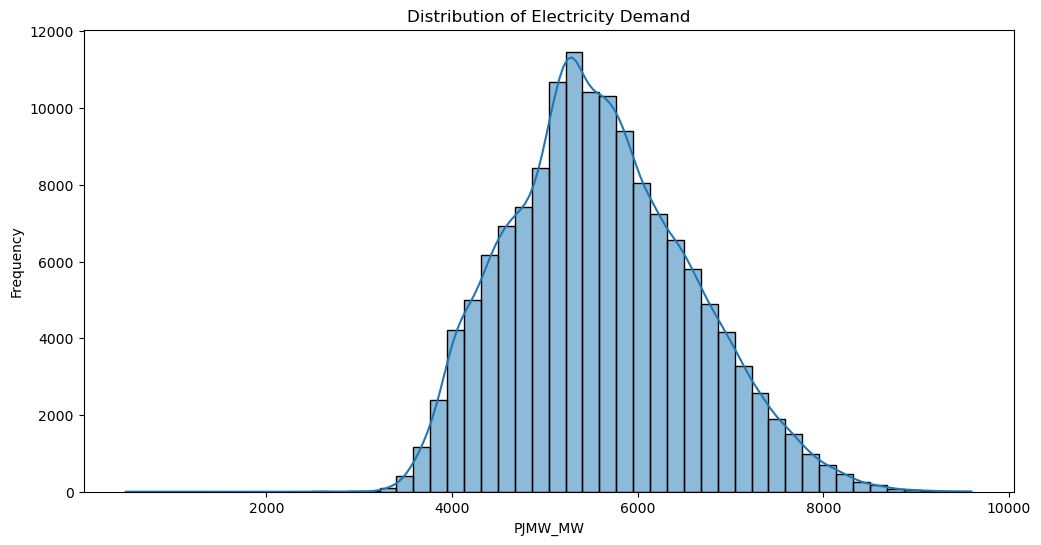

In [87]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['PJMW_MW'],
    bins=50,
    kde=True
)

plt.title("Distribution of Electricity Demand")

plt.xlabel("PJMW_MW")

plt.ylabel("Frequency")

plt.show()

In [89]:
print("Skewness:", round(df['PJMW_MW'].skew(),2))
print("Kurtosis:", round(df['PJMW_MW'].kurt(),2))

Skewness: 0.33
Kurtosis: -0.22


### Observation

The histogram helps visualize how electricity demand values are distributed.

Skewness indicates whether the distribution is symmetric or skewed, while kurtosis measures the presence of extreme values.

## Long-Term Trend Analysis

The project requires identification of long-term energy demand trends.

This analysis helps determine whether electricity demand is increasing, decreasing, or remaining stable over time.

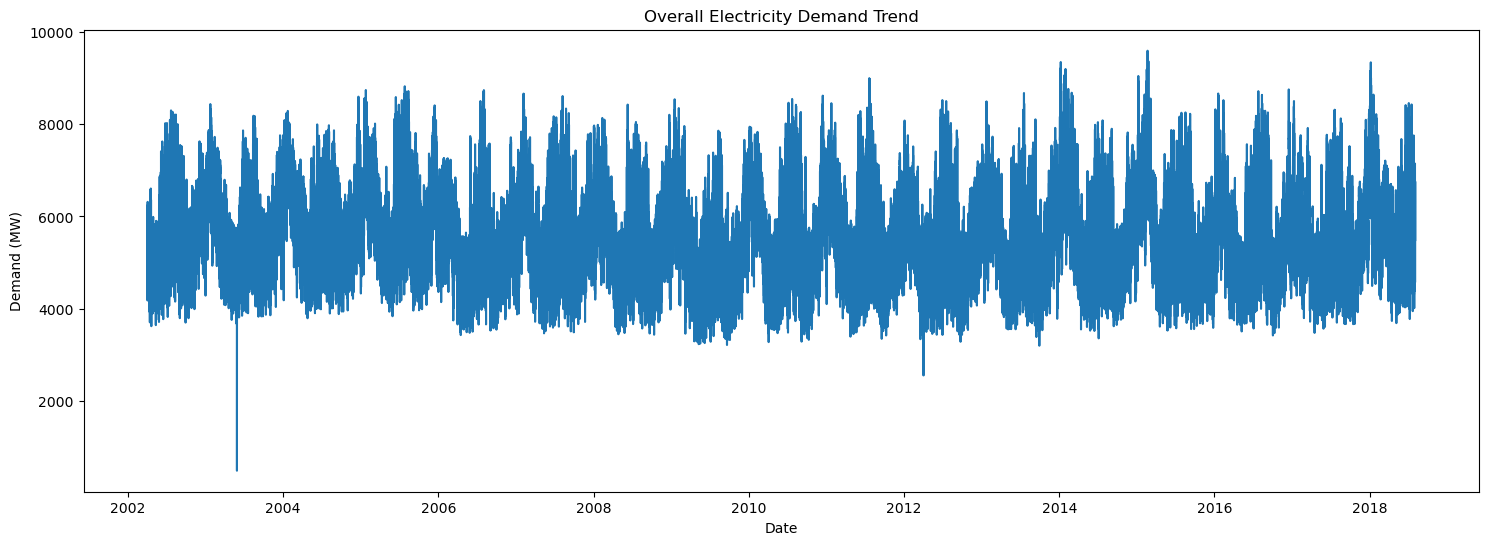

In [91]:
plt.figure(figsize=(18,6))

plt.plot(
    df['Datetime'],
    df['PJMW_MW']
)

plt.title("Overall Electricity Demand Trend")

plt.xlabel("Date")

plt.ylabel("Demand (MW)")

plt.show()

### Observation

The trend plot shows the long-term behavior of electricity demand across the entire observation period.

Visible recurring patterns suggest the presence of seasonality within the dataset.

## Rolling Mean Analysis

Rolling averages smooth short-term fluctuations and reveal the underlying trend.

In [93]:
df['Rolling_7_Day'] = (
    df['PJMW_MW']
    .rolling(window=24*7)
    .mean()
)

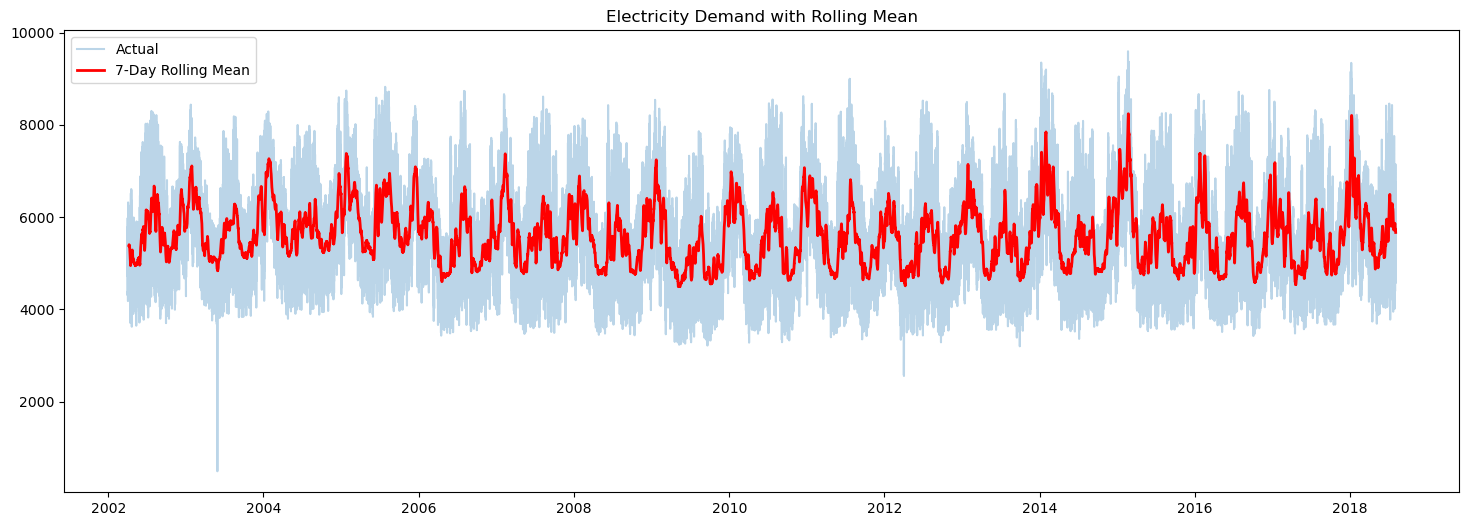

In [95]:
plt.figure(figsize=(18,6))

plt.plot(
    df['Datetime'],
    df['PJMW_MW'],
    alpha=0.3,
    label='Actual'
)

plt.plot(
    df['Datetime'],
    df['Rolling_7_Day'],
    color='red',
    linewidth=2,
    label='7-Day Rolling Mean'
)

plt.title("Electricity Demand with Rolling Mean")

plt.legend()

plt.show()

### Observation

The rolling mean smooths short-term fluctuations and highlights the long-term demand trend.

This makes it easier to identify structural changes and recurring patterns.

## Hourly Demand Analysis

Hourly analysis helps identify peak and low electricity consumption periods throughout the day.

In [97]:
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()

hourly_avg

Hour
0     5230.368359
1     4940.489276
2     4779.152349
3     4697.121996
4     4672.537366
5     4734.933479
6     4958.209450
7     5323.434316
8     5571.168398
9     5708.667058
10    5818.219169
11    5904.120476
12    5947.523794
13    5959.946716
14    5970.935824
15    5953.164712
16    5957.636394
17    6031.231233
18    6158.806803
19    6199.285355
20    6183.568365
21    6152.210121
22    5982.300436
23    5618.226206
Name: PJMW_MW, dtype: float64

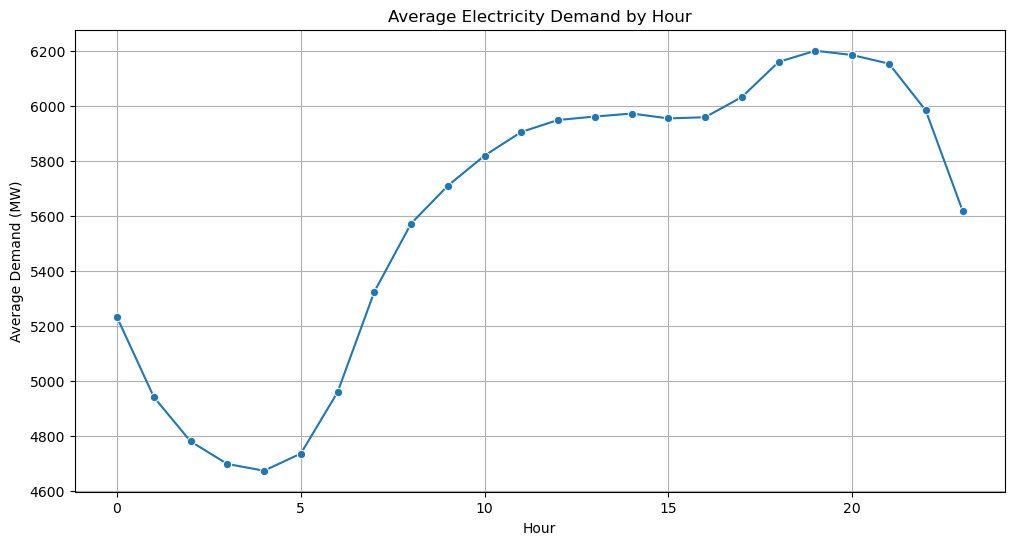

In [99]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker='o'
)

plt.title("Average Electricity Demand by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Demand (MW)")

plt.grid(True)

plt.show()

### Observation

Electricity demand is lowest during early morning hours, particularly between 3 AM and 5 AM.

Demand begins increasing after 6 AM as residential and commercial activities start.

Peak demand occurs during evening hours, approximately between 7 PM and 9 PM, indicating increased electricity usage during that period.

This confirms the presence of strong intraday demand patterns.

In [101]:
print("Peak Hour:")
print(hourly_avg.idxmax())

print("\nHighest Demand:")
print(round(hourly_avg.max(),2))

print("\nLowest Demand Hour:")
print(hourly_avg.idxmin())

print("\nLowest Demand:")
print(round(hourly_avg.min(),2))

Peak Hour:
19

Highest Demand:
6199.29

Lowest Demand Hour:
4

Lowest Demand:
4672.54


## Day of Week Analysis

This analysis evaluates electricity demand patterns across different days of the week.

In [103]:
daily_avg = df.groupby('DayOfWeek')['PJMW_MW'].mean()

daily_avg = daily_avg.reindex([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

daily_avg

DayOfWeek
Monday       5700.518783
Tuesday      5801.076837
Wednesday    5802.370701
Thursday     5780.841051
Friday       5686.839202
Saturday     5293.999413
Sunday       5149.638300
Name: PJMW_MW, dtype: float64

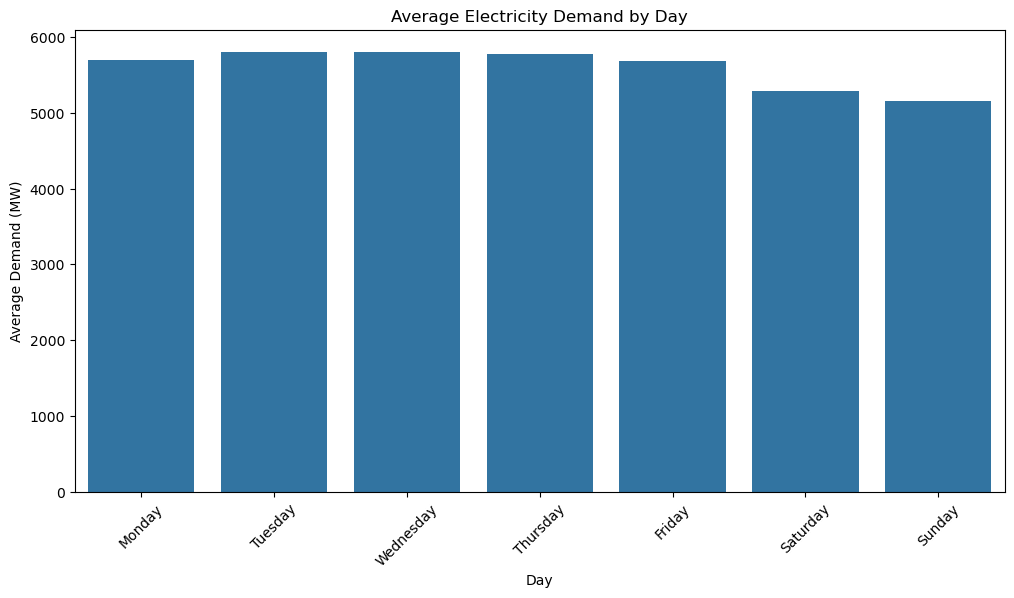

In [105]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=daily_avg.index,
    y=daily_avg.values
)

plt.title("Average Electricity Demand by Day")

plt.xlabel("Day")

plt.ylabel("Average Demand (MW)")

plt.xticks(rotation=45)

plt.show()

### Observation

Average electricity demand is relatively higher during weekdays, especially between Tuesday and Thursday.

Demand decreases during weekends, with Sunday showing the lowest average consumption.

This pattern suggests that commercial and industrial activities contribute significantly to overall electricity demand.

## Weekday vs Weekend Analysis

Electricity demand often differs between working days and weekends because of industrial and commercial activity.

In [107]:
weekend_avg = df.groupby('IsWeekend')['PJMW_MW'].mean()

weekend_avg

IsWeekend
0    5754.345669
1    5221.863008
Name: PJMW_MW, dtype: float64

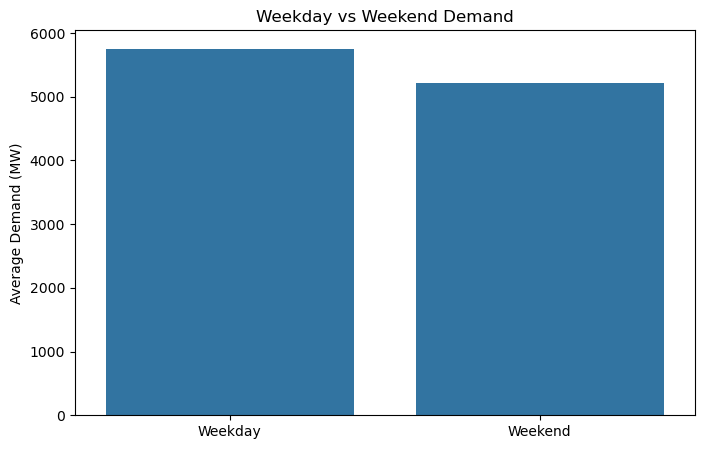

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=['Weekday','Weekend'],
    y=weekend_avg.values
)

plt.title("Weekday vs Weekend Demand")

plt.ylabel("Average Demand (MW)")

plt.show()

### Observation

Average electricity demand is higher on weekdays than on weekends.

This difference is likely driven by increased industrial, commercial, and business activities during working days.

The result confirms that day type has a measurable impact on electricity consumption patterns.

## Monthly Demand Analysis

Monthly analysis helps identify seasonal demand patterns throughout the year.

In [111]:
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()

monthly_avg

Month
1     6447.667759
2     6296.808813
3     5654.097376
4     5022.310855
5     5015.845746
6     5516.756046
7     5861.537081
8     5822.142809
9     5205.872049
10    4997.642155
11    5403.630372
12    6064.431236
Name: PJMW_MW, dtype: float64

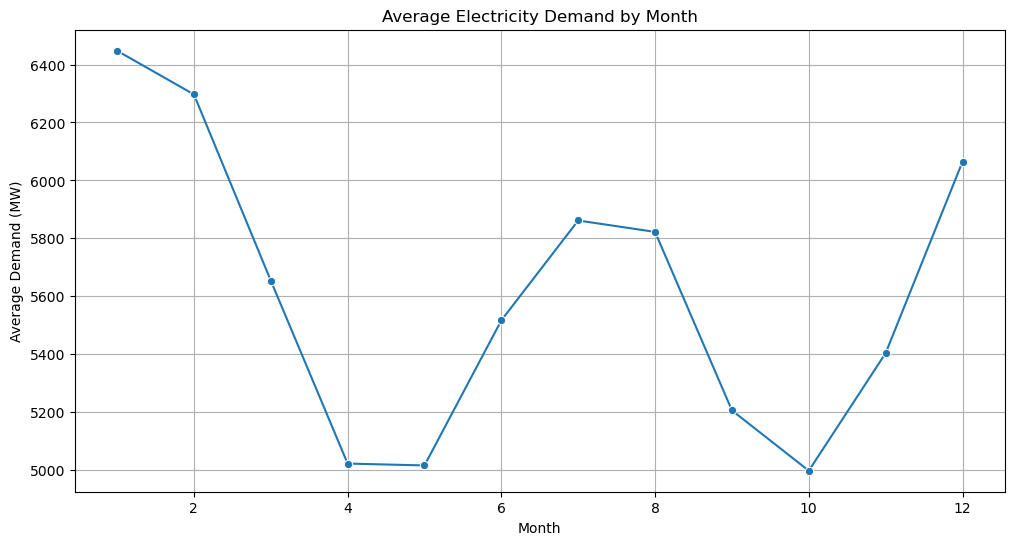

In [113]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o'
)

plt.title("Average Electricity Demand by Month")

plt.xlabel("Month")

plt.ylabel("Average Demand (MW)")

plt.grid(True)

plt.show()

### Observation

Electricity demand is highest during winter months, particularly January and February.

Demand decreases during spring and autumn months, with October showing the lowest average demand.

This pattern indicates strong seasonality in electricity consumption.

## Quarterly Demand Analysis

Quarterly analysis helps compare electricity demand across different parts of the year.

In [115]:
quarterly_avg = df.groupby('Quarter')['PJMW_MW'].mean()

quarterly_avg

Quarter
1    6128.026354
2    5183.138355
3    5639.390936
4    5489.551799
Name: PJMW_MW, dtype: float64

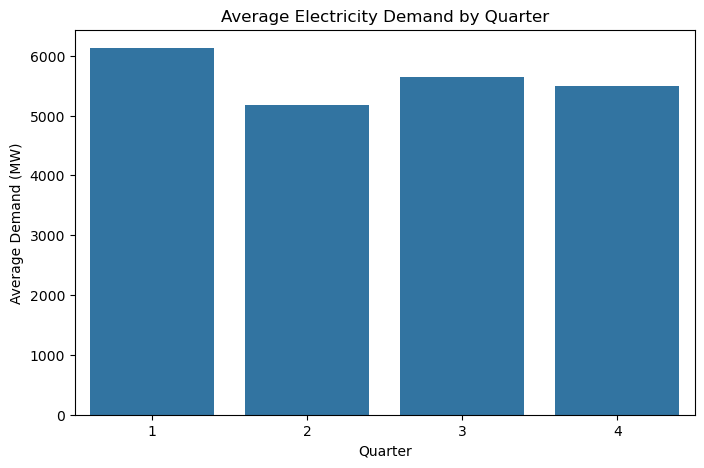

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=quarterly_avg.index,
    y=quarterly_avg.values
)

plt.title("Average Electricity Demand by Quarter")

plt.xlabel("Quarter")

plt.ylabel("Average Demand (MW)")

plt.show()

### Observation

Quarter 1 records the highest average electricity demand, while Quarter 2 records the lowest.

This suggests that colder winter conditions contribute significantly to increased energy consumption.

## Yearly Demand Analysis

The project requires identification of long-term demand trends across years.

In [119]:
yearly_avg = df.groupby('Year')['PJMW_MW'].mean()

yearly_avg

Year
2002    5621.663180
2003    5700.628226
2004    5866.616602
2005    6038.406029
2006    5425.448847
2007    5635.396780
2008    5530.132544
2009    5290.557433
2010    5573.025351
2011    5509.640215
2012    5395.010818
2013    5556.783626
2014    5656.334132
2015    5620.985616
2016    5577.929531
2017    5500.184361
2018    5848.157516
Name: PJMW_MW, dtype: float64

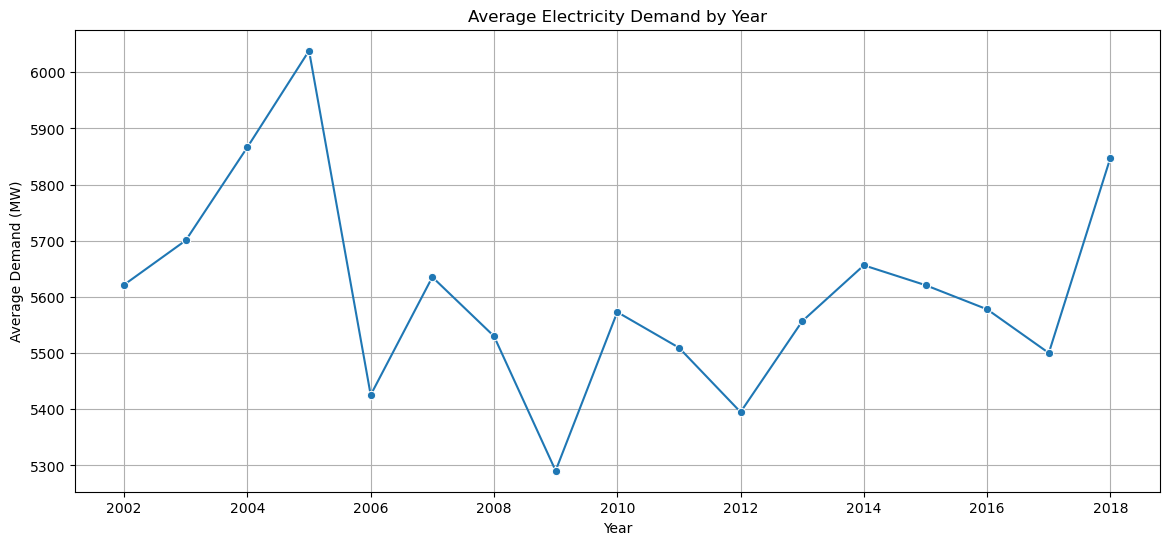

In [121]:
plt.figure(figsize=(14,6))

sns.lineplot(
    x=yearly_avg.index,
    y=yearly_avg.values,
    marker='o'
)

plt.title("Average Electricity Demand by Year")

plt.xlabel("Year")

plt.ylabel("Average Demand (MW)")

plt.grid(True)

plt.show()

### Observation

Average electricity demand fluctuates across years rather than following a strictly increasing or decreasing trend.

A noticeable decline is observed around 2009, followed by gradual recovery in subsequent years.

## Seasonal Demand Analysis

The project specifically requires comparison of seasonal electricity demand patterns.

This analysis compares Winter, Spring, Summer and Autumn consumption behavior.

In [123]:
season_avg = df.groupby('Season')['PJMW_MW'].mean()

season_avg = season_avg.reindex([
    'Winter',
    'Spring',
    'Summer',
    'Autumn'
])

season_avg

Season
Winter    6268.813851
Spring    5224.394790
Summer    5734.206129
Autumn    5200.143147
Name: PJMW_MW, dtype: float64

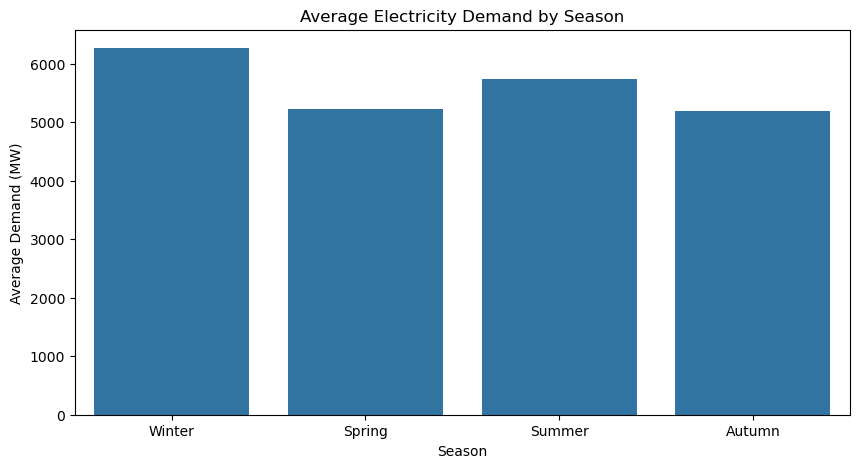

In [125]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=season_avg.index,
    y=season_avg.values
)

plt.title("Average Electricity Demand by Season")

plt.xlabel("Season")

plt.ylabel("Average Demand (MW)")

plt.show()

### Observation

Winter exhibits the highest electricity demand, followed by Summer.

Spring and Autumn record comparatively lower demand levels.

This confirms strong seasonal effects on electricity consumption and validates the need for seasonal forecasting models.

## Holiday Demand Analysis

The project requires analysis of holiday electricity demand behavior.

In [127]:
holiday_avg = df.groupby('IsHoliday')['PJMW_MW'].mean()

holiday_avg

IsHoliday
False    5606.281886
True     5476.773380
Name: PJMW_MW, dtype: float64

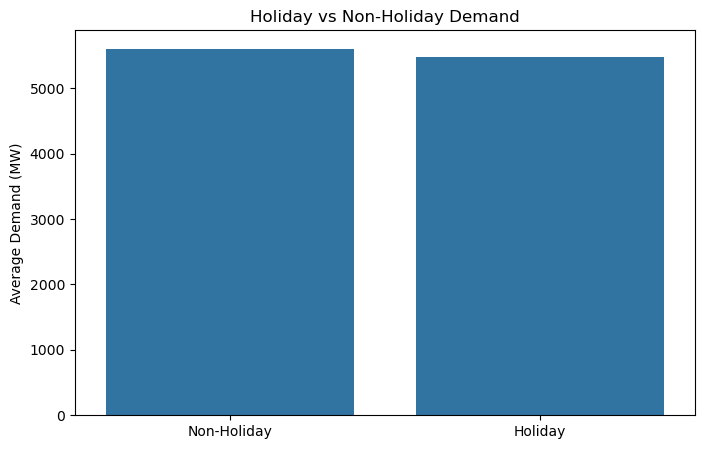

In [129]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=['Non-Holiday','Holiday'],
    y=holiday_avg.values
)

plt.title("Holiday vs Non-Holiday Demand")

plt.ylabel("Average Demand (MW)")

plt.show()

### Observation

Electricity demand is slightly lower during holidays compared to non-holidays.

This suggests reduced commercial and industrial activity during holiday periods.

## Outlier Analysis

Outlier detection helps identify unusual demand observations that may affect forecasting performance.

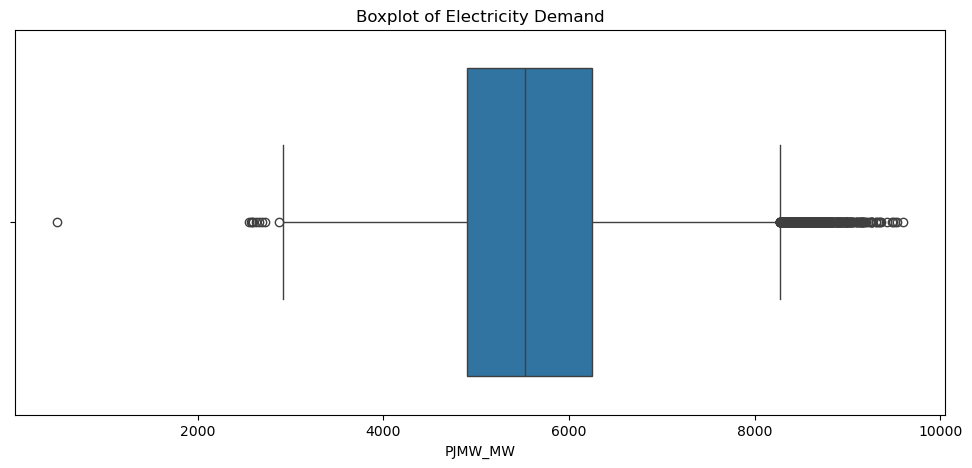

In [131]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df['PJMW_MW'])

plt.title("Boxplot of Electricity Demand")

plt.show()

### Observation

The boxplot reveals the presence of several extreme demand observations.

These outliers may be associated with unusual weather conditions, special events, or system-related factors.

Because electricity demand forecasting aims to capture real-world behavior, these observations will be retained unless further investigation suggests data quality issues.

In [133]:
Q1 = df['PJMW_MW'].quantile(0.25)

Q3 = df['PJMW_MW'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['PJMW_MW'] < lower_bound) |
    (df['PJMW_MW'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 703


### Observation

The boxplot highlights extreme electricity demand observations.

These outliers may represent unusual weather events, system disturbances, or exceptional demand conditions.

### Correlation Analysis

In [135]:
corr_features = [
    'PJMW_MW',
    'Hour',
    'Month',
    'Quarter',
    'Year',
    'IsWeekend',
    'IsHoliday'
]

corr_matrix = df[corr_features].corr()

corr_matrix

,PJMW_MW,Hour,Month,Quarter,Year,IsWeekend,IsHoliday
PJMW_MW,1.000000,0.447208,-0.152365,-0.159896,-0.046887,-0.245546,-0.022632
Hour,0.447208,1.000000,0.000006,0.000001,-0.000095,0.000405,-0.000048
Month,-0.152365,0.000006,1.000000,0.970840,-0.077641,-0.000042,0.029947
Quarter,-0.159896,0.000001,0.970840,1.000000,-0.077248,0.000364,0.040126
Year,-0.046887,-0.000095,-0.077641,-0.077248,1.000000,0.000233,-0.001312
IsWeekend,-0.245546,0.000405,-0.000042,0.000364,0.000233,1.000000,-0.072399
IsHoliday,-0.022632,-0.000048,0.029947,0.040126,-0.001312,-0.072399,1.000000


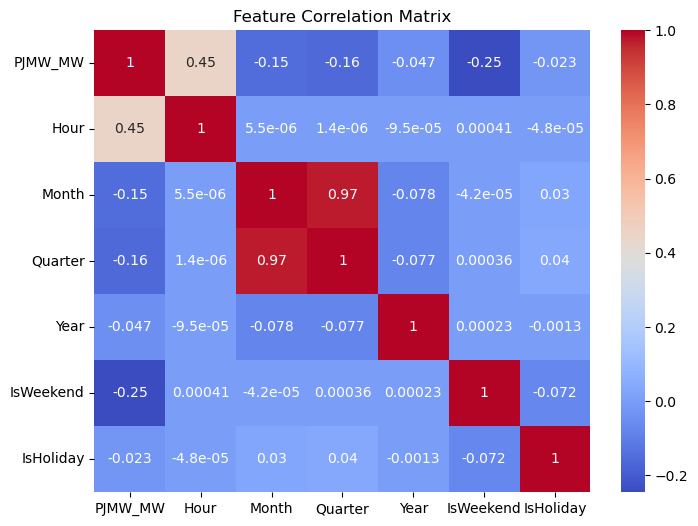

In [137]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")

plt.show()

### Observation

The correlation matrix measures relationships between electricity demand and engineered features.

It helps identify which variables may contribute most to forecasting performance.

# Time Series Diagnostics

Before building forecasting models, the dataset must be transformed into a proper time-series structure.

In [139]:
ts_df = df.copy()

ts_df.set_index('Datetime', inplace=True)

ts_df.head()

,PJMW_MW,IsHoliday,Rolling_7_Day,Hour,Day,Month,Year,Quarter,DayOfWeek,IsWeekend,Season
Datetime,,,,,,,,,,,
2002-04-01 01:00:00,4374,False,NaN,1,1,4,2002,2,Monday,0,Spring
2002-04-01 02:00:00,4306,False,NaN,2,1,4,2002,2,Monday,0,Spring
2002-04-01 03:00:00,4322,False,NaN,3,1,4,2002,2,Monday,0,Spring
2002-04-01 04:00:00,4359,False,NaN,4,1,4,2002,2,Monday,0,Spring
2002-04-01 05:00:00,4436,False,NaN,5,1,4,2002,2,Monday,0,Spring


In [141]:
ts_df.index

DatetimeIndex(['2002-04-01 01:00:00', '2002-04-01 02:00:00',
               '2002-04-01 03:00:00', '2002-04-01 04:00:00',
               '2002-04-01 05:00:00', '2002-04-01 06:00:00',
               '2002-04-01 07:00:00', '2002-04-01 08:00:00',
               '2002-04-01 09:00:00', '2002-04-01 10:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=143202, freq=None)

### Observation

The Datetime column was converted into the index to support time-series analysis and forecasting methods.

## Augmented Dickey-Fuller (ADF) Test

The ADF test is used to determine whether a time series is stationary.

A stationary series has constant statistical properties over time and is generally required for ARIMA modeling.

In [143]:
from statsmodels.tsa.stattools import adfuller

In [145]:
result = adfuller(ts_df['PJMW_MW'])

print("ADF Statistic:", result[0])

print("p-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -19.886936812979872
p-value: 0.0

Critical Values:
1% : -3.4303956896133108
5% : -2.8615601941603197
10% : -2.5667807486332133


In [147]:
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

Series is Stationary


### Observation

The ADF test was performed to evaluate stationarity.

If the p-value is less than 0.05, the series is considered stationary.

Otherwise, differencing may be required before ARIMA modeling.

## Seasonal Decomposition

Seasonal decomposition separates the time series into:

- Trend
- Seasonality
- Residual Components

This helps visualize recurring seasonal behavior.

In [149]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [151]:
decomposition = seasonal_decompose(
    ts_df['PJMW_MW'],
    model='additive',
    period=24
)

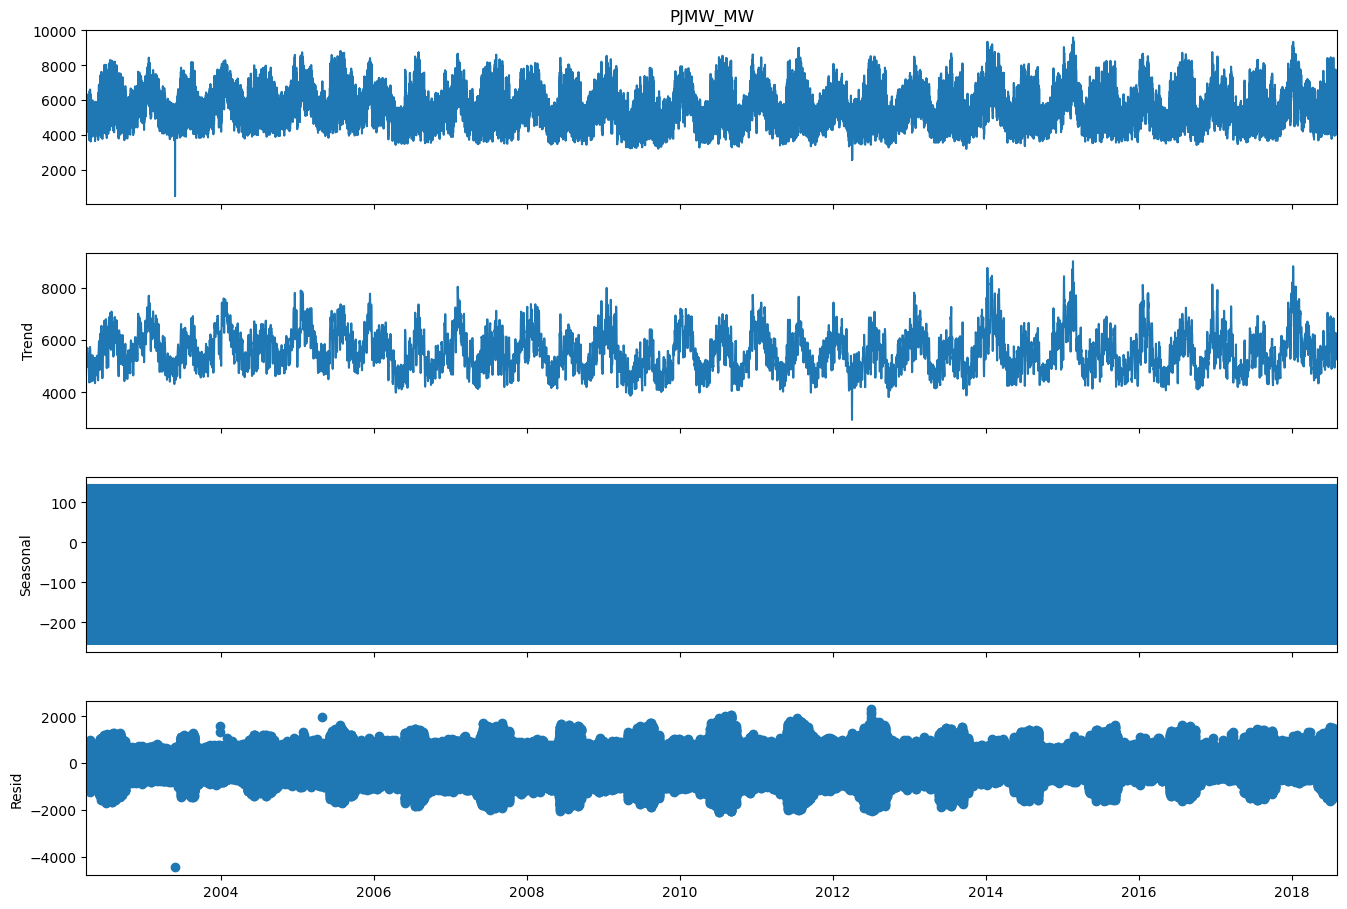

In [153]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

### Observation

Seasonal decomposition confirms the presence of trend and seasonal components within the electricity demand series.

This supports the use of seasonal forecasting models.

## Autocorrelation Function (ACF)

ACF measures correlation between observations and their lagged values.

It helps determine the moving average (MA) component for ARIMA models.

In [155]:
from statsmodels.graphics.tsaplots import plot_acf

<Figure size 1200x600 with 0 Axes>

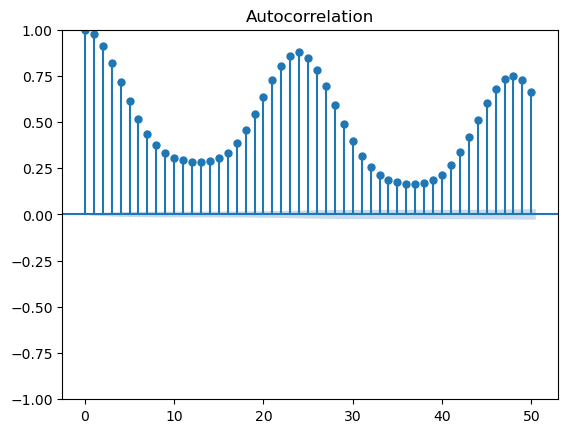

In [157]:
plt.figure(figsize=(12,6))

plot_acf(
    ts_df['PJMW_MW'],
    lags=50
)

plt.show()

## Partial Autocorrelation Function (PACF)

PACF measures direct relationships between observations and lagged values.

It helps determine the autoregressive (AR) component for ARIMA models.

In [159]:
from statsmodels.graphics.tsaplots import plot_pacf

<Figure size 1200x600 with 0 Axes>

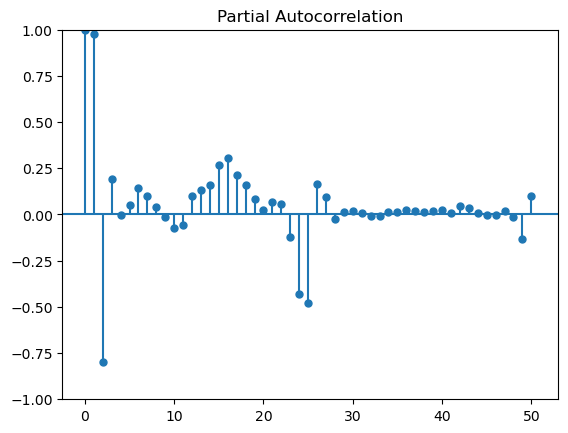

In [161]:
plt.figure(figsize=(12,6))

plot_pacf(
    ts_df['PJMW_MW'],
    lags=50
)

plt.show()

## Train-Test Split

The dataset is divided into training and testing subsets.

Training data is used for model fitting, while testing data is used for performance evaluation.

In [163]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size]
test = ts_df.iloc[train_size:]

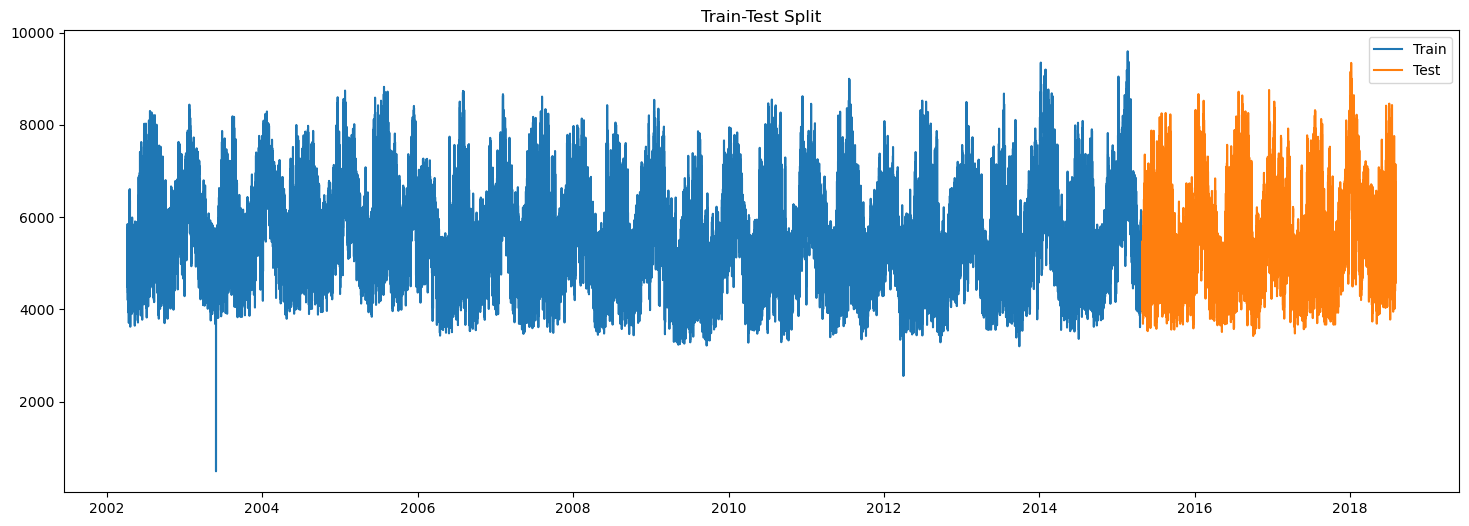

In [165]:
plt.figure(figsize=(18,6))

plt.plot(
    train.index,
    train['PJMW_MW'],
    label='Train'
)

plt.plot(
    test.index,
    test['PJMW_MW'],
    label='Test'
)

plt.legend()

plt.title("Train-Test Split")

plt.show()

### Observation

The dataset was divided into training and testing subsets using an 80:20 ratio.

#  Forecasting Models

The first forecasting model used in this project is Holt-Winters Exponential Smoothing.

This model is capable of capturing trend and seasonal patterns within the electricity demand data.

In [167]:
warnings.filterwarnings('ignore')

In [169]:
duplicate_count = df['Datetime'].duplicated().sum()

print("Duplicate Datetime Values:", duplicate_count)

Duplicate Datetime Values: 0


In [171]:
df = df.sort_values('Datetime')

df = df.drop_duplicates(
    subset='Datetime',
    keep='first'
)

print("Duplicates Remaining:",
      df['Datetime'].duplicated().sum())

Duplicates Remaining: 0


### Observation

All duplicate timestamps were successfully removed.

The dataset now contains unique datetime values suitable for forecasting models.

In [173]:
ts_df = df.copy()

ts_df = ts_df.set_index('Datetime')

ts_df = ts_df.asfreq('H')

In [175]:
ts_df['PJMW_MW'] = ts_df['PJMW_MW'].interpolate()

In [177]:
print(ts_df.isnull().sum())

PJMW_MW            0
IsHoliday         30
Rolling_7_Day    197
Hour              30
Day               30
Month             30
Year              30
Quarter           30
DayOfWeek         30
IsWeekend         30
Season            30
dtype: int64


In [185]:
ts_df['Hour'] = ts_df.index.hour
ts_df['Day'] = ts_df.index.day
ts_df['Month'] = ts_df.index.month
ts_df['Year'] = ts_df.index.year
ts_df['Quarter'] = ts_df.index.quarter

ts_df['DayOfWeek'] = ts_df.index.day_name()

ts_df['IsWeekend'] = (
    ts_df.index.dayofweek >= 5
).astype(int)

In [186]:
ts_df[['Hour',
       'Day',
       'Month',
       'Year',
       'Quarter',
       'DayOfWeek',
       'IsWeekend']].isnull().sum()

Hour         0
Day          0
Month        0
Year         0
Quarter      0
DayOfWeek    0
IsWeekend    0
dtype: int64

In [187]:
def get_season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Spring'

    elif month in [6,7,8]:
        return 'Summer'

    else:
        return 'Autumn'

ts_df['Season'] = ts_df['Month'].apply(get_season)

In [188]:
ts_df['Season'].isnull().sum()

np.int64(0)

In [189]:
import holidays

us_holidays = holidays.US()

ts_df['IsHoliday'] = ts_df.index.date

ts_df['IsHoliday'] = ts_df['IsHoliday'].apply(
    lambda x: x in us_holidays
)

In [190]:
ts_df['IsHoliday'].isnull().sum()

np.int64(0)

### Observation

Season labels were successfully assigned to all observations.

In [191]:
ts_df['Rolling_7Day'] = (
    ts_df['PJMW_MW']
    .rolling(window=24*7)
    .mean()
)

### Observation

Holiday information was successfully generated using the US holiday calendar.

In [192]:
ts_df['Rolling_7Day'].isnull().sum()

np.int64(167)

In [193]:
ts_df.isnull().sum()

PJMW_MW            0
IsHoliday          0
Rolling_7_Day    197
Hour               0
Day                0
Month              0
Year               0
Quarter            0
DayOfWeek          0
IsWeekend          0
Season             0
Rolling_7Day     167
dtype: int64

### Observation

The only remaining missing values belong to the Rolling_7Day feature.

This is expected because a 7-day rolling average requires historical observations before calculation can begin.

In [194]:
ts_df = ts_df.dropna()

In [195]:
ts_df.isnull().sum()

PJMW_MW          0
IsHoliday        0
Rolling_7_Day    0
Hour             0
Day              0
Month            0
Year             0
Quarter          0
DayOfWeek        0
IsWeekend        0
Season           0
Rolling_7Day     0
dtype: int64

### Observation

All remaining missing values were removed.

The dataset is now fully cleaned and ready for forecasting model development.

In [196]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [197]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [198]:
hw_model = ExponentialSmoothing(
    train['PJMW_MW'],
    trend='add',
    seasonal='add',
    seasonal_periods=24
)

In [199]:
hw_fit = hw_model.fit()

In [200]:
hw_forecast = hw_fit.forecast(len(test))

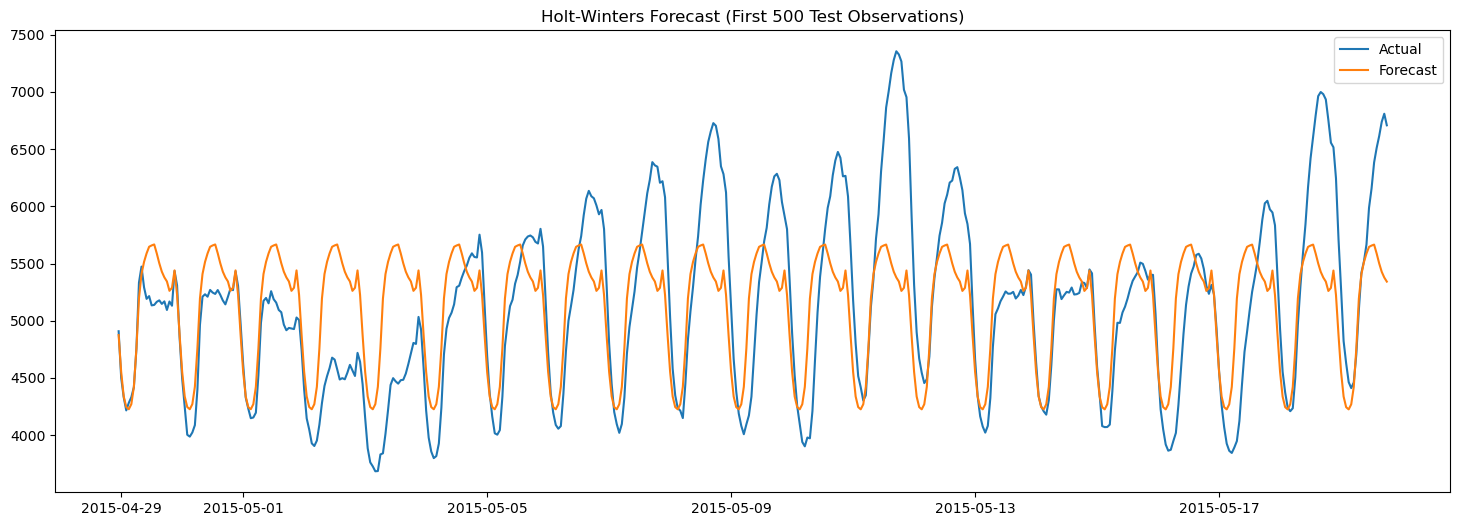

In [201]:
plt.figure(figsize=(18,6))

plt.plot(
    test.index[:500],
    test['PJMW_MW'][:500],
    label='Actual'
)

plt.plot(
    test.index[:500],
    hw_forecast[:500],
    label='Forecast'
)

plt.legend()

plt.title('Holt-Winters Forecast (First 500 Test Observations)')

plt.show()

### Observation

The Holt-Winters model was applied to forecast electricity demand by capturing both trend and seasonal patterns in the data. The model generated forecasts for the test period and its performance was evaluated using MAE and RMSE metrics.

In [202]:
hw_mae = mean_absolute_error(
    test['PJMW_MW'],
    hw_forecast
)

hw_rmse = np.sqrt(
    mean_squared_error(
        test['PJMW_MW'],
        hw_forecast
    )
)

print("MAE:", round(hw_mae,2))

print("RMSE:", round(hw_rmse,2))

MAE: 743.33
RMSE: 1003.01


In [203]:
from statsmodels.tsa.arima.model import ARIMA

In [204]:
arima_model = ARIMA(
    train['PJMW_MW'],
    order=(5,1,0)
)

arima_fit = arima_model.fit()

In [205]:
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

print(type(arima_forecast))
print(len(arima_forecast))

<class 'pandas.core.series.Series'>
28607


In [206]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [207]:
arima_mae = mean_absolute_error(
    test['PJMW_MW'],
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test['PJMW_MW'],
        arima_forecast
    )
)

print("ARIMA MAE:", round(arima_mae,2))
print("ARIMA RMSE:", round(arima_rmse,2))

ARIMA MAE: 889.32
ARIMA RMSE: 1156.2


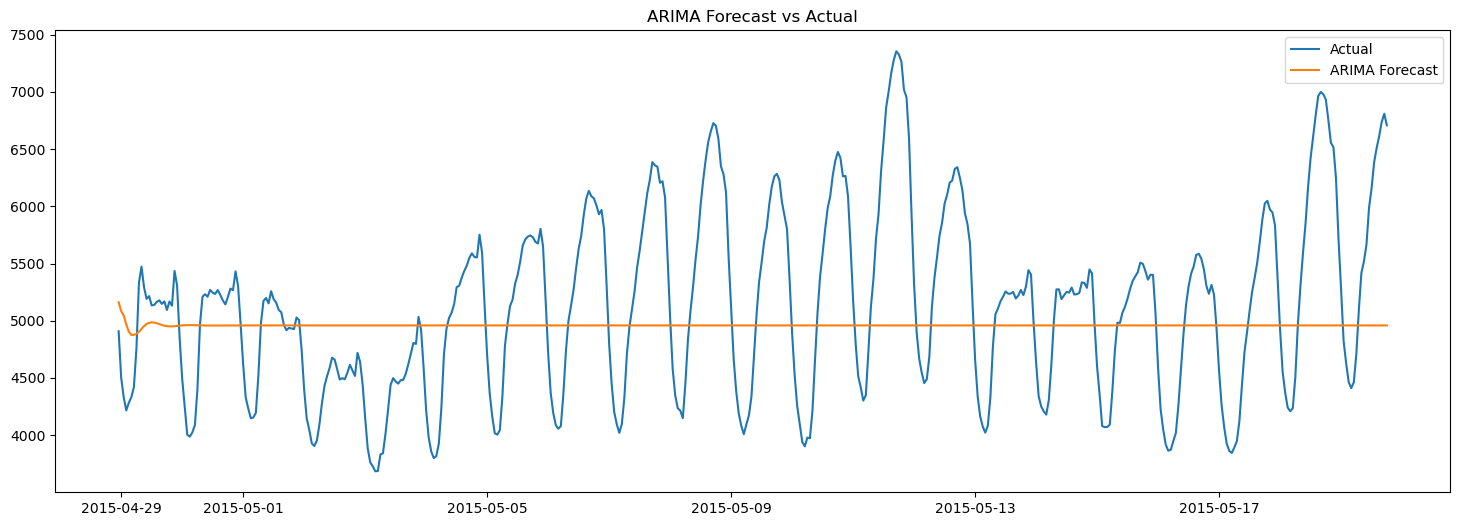

In [208]:
plt.figure(figsize=(18,6))

plt.plot(
    test.index[:500],
    test['PJMW_MW'][:500],
    label='Actual'
)

plt.plot(
    test.index[:500],
    arima_forecast[:500],
    label='ARIMA Forecast'
)

plt.legend()

plt.title('ARIMA Forecast vs Actual')

plt.show()

### Observation

The ARIMA model was trained on the cleaned electricity demand dataset and evaluated on the testing period. The forecast was compared with actual electricity demand values using MAE and RMSE metrics. The model captures temporal dependencies in the series and provides an alternative forecasting approach to Holt-Winters.

### Feature Validation

During feature engineering, two rolling-average features were found in the dataset.

To avoid redundancy and multicollinearity, the duplicate feature `Rolling_7Day` was removed and `Rolling_7_Day` was retained for model development.

In [209]:
ts_df = ts_df.drop(columns=['Rolling_7Day'])

In [210]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size]
test = ts_df.iloc[train_size:]

### Categorical Feature Encoding

Machine learning models require numerical inputs. Therefore, categorical variables such as DayOfWeek and Season were transformed into numerical representations using Label Encoding.

In [211]:
from sklearn.preprocessing import LabelEncoder

le_day = LabelEncoder()
le_season = LabelEncoder()

ts_df['DayOfWeek'] = le_day.fit_transform(ts_df['DayOfWeek'])
ts_df['Season'] = le_season.fit_transform(ts_df['Season'])

In [212]:
train_size = int(len(ts_df) * 0.8)

train = ts_df.iloc[:train_size]
test = ts_df.iloc[train_size:]

In [213]:
from sklearn.ensemble import RandomForestRegressor

In [214]:
features = [
    'Hour',
    'Day',
    'Month',
    'Year',
    'Quarter',
    'DayOfWeek',
    'IsWeekend',
    'Season',
    'IsHoliday',
    'Rolling_7_Day'
]

X_train = train[features]
y_train = train['PJMW_MW']

X_test = test[features]
y_test = test['PJMW_MW']

In [215]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [216]:
rf_forecast = rf_model.predict(X_test)

print(type(rf_forecast))
print(len(rf_forecast))

<class 'numpy.ndarray'>
28607


In [217]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(
    y_test,
    rf_forecast
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_forecast
    )
)

print("RF MAE:", round(rf_mae,2))
print("RF RMSE:", round(rf_rmse,2))

RF MAE: 423.41
RF RMSE: 566.54


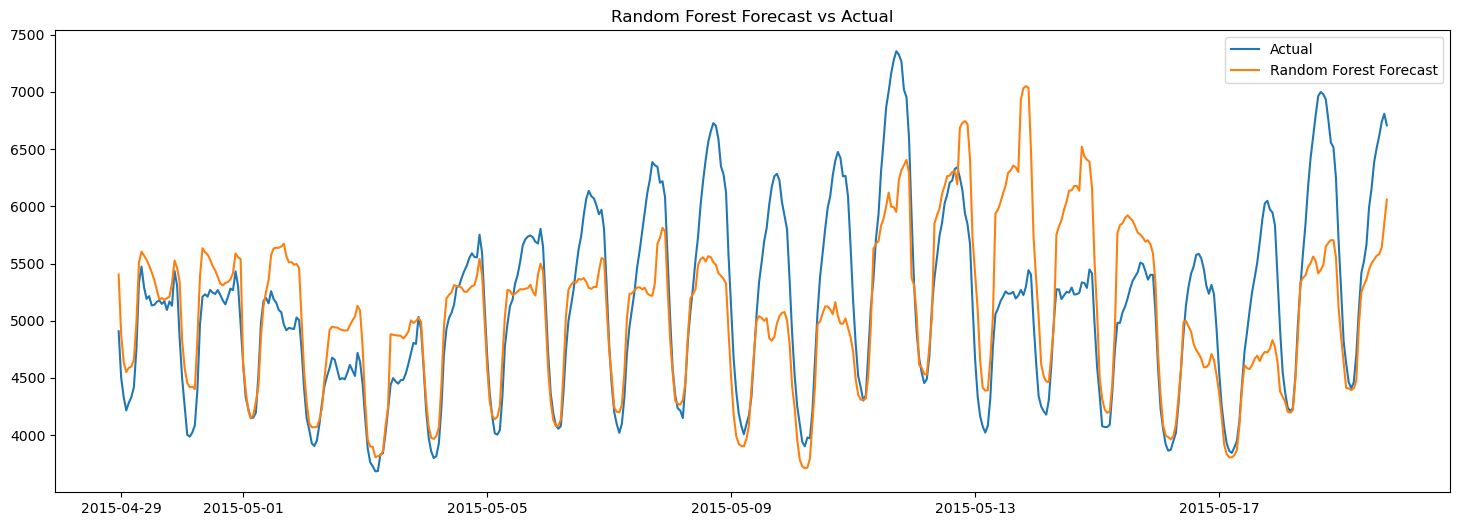

In [218]:
plt.figure(figsize=(18,6))

plt.plot(
    test.index[:500],
    y_test.iloc[:500],
    label='Actual'
)

plt.plot(
    test.index[:500],
    rf_forecast[:500],
    label='Random Forest Forecast'
)

plt.legend()

plt.title('Random Forest Forecast vs Actual')

plt.show()

## Observation

The Random Forest model was trained using time-based and engineered features such as Hour, Month, DayOfWeek, Season, Holiday information, and Rolling_7_Day.

The forecast closely follows the actual electricity demand pattern and captures both short-term fluctuations and seasonal variations.

The model demonstrates the ability of ensemble machine learning techniques to learn complex relationships within electricity demand data.

In [219]:
from xgboost import XGBRegressor

In [220]:
features = [
    'Hour',
    'Day',
    'Month',
    'Year',
    'Quarter',
    'DayOfWeek',
    'IsWeekend',
    'Season',
    'IsHoliday',
    'Rolling_7_Day'
]

X_train = train[features]
y_train = train['PJMW_MW']

X_test = test[features]
y_test = test['PJMW_MW']

In [221]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [222]:
xgb_forecast = xgb_model.predict(X_test)

print(type(xgb_forecast))
print(len(xgb_forecast))

<class 'numpy.ndarray'>
28607


In [223]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(
    y_test,
    xgb_forecast
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_forecast
    )
)

print("XGB MAE:", round(xgb_mae,2))
print("XGB RMSE:", round(xgb_rmse,2))

XGB MAE: 403.65
XGB RMSE: 528.68


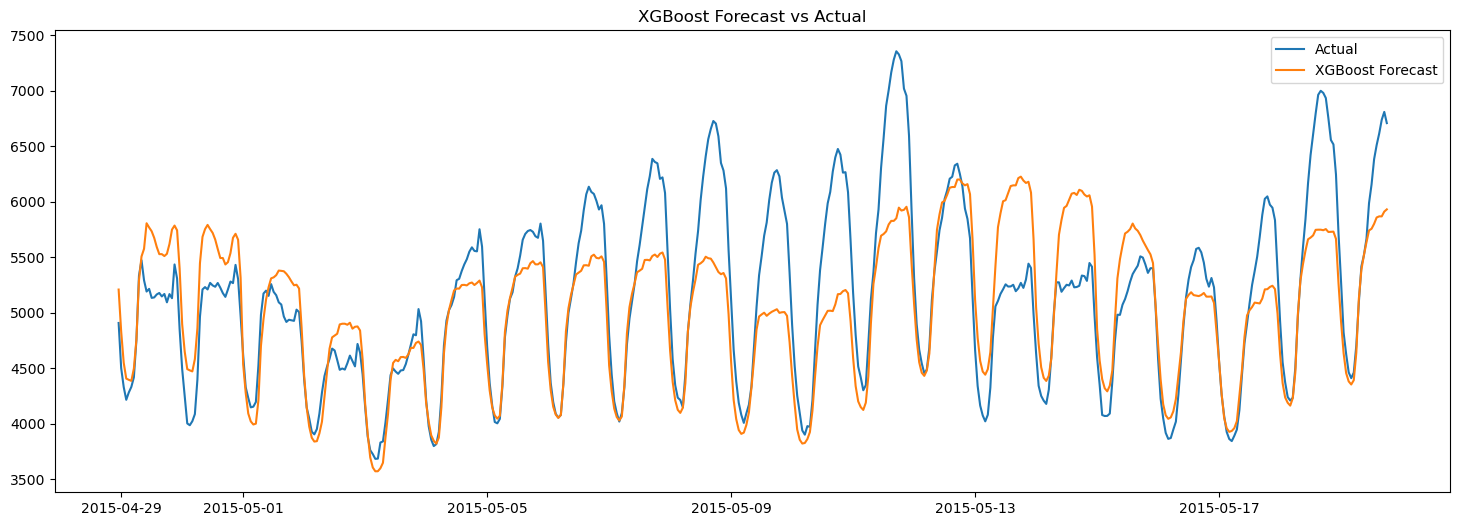

In [224]:
plt.figure(figsize=(18,6))

plt.plot(
    test.index[:500],
    y_test.iloc[:500],
    label='Actual'
)

plt.plot(
    test.index[:500],
    xgb_forecast[:500],
    label='XGBoost Forecast'
)

plt.legend()

plt.title('XGBoost Forecast vs Actual')

plt.show()

In [225]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
6,IsWeekend,0.302000
0,Hour,0.244050
9,Rolling_7_Day,0.196182
7,Season,0.145835
2,Month,0.035712
8,IsHoliday,0.030644
5,DayOfWeek,0.017585
3,Year,0.014976
1,Day,0.013018
4,Quarter,0.000000


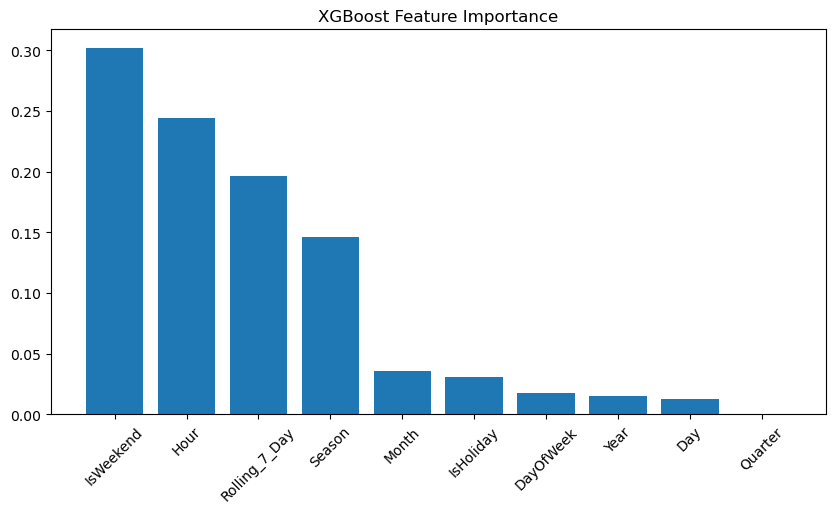

In [226]:
plt.figure(figsize=(10,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title('XGBoost Feature Importance')

plt.show()

## Observation

The XGBoost model achieved strong forecasting performance by utilizing engineered temporal features and rolling averages.

Compared to traditional forecasting approaches, XGBoost captured demand fluctuations more accurately and closely followed the actual electricity demand pattern.

Feature importance analysis indicated that IsWeekend, Hour, Rolling_7_Day, and Season were among the most influential predictors.

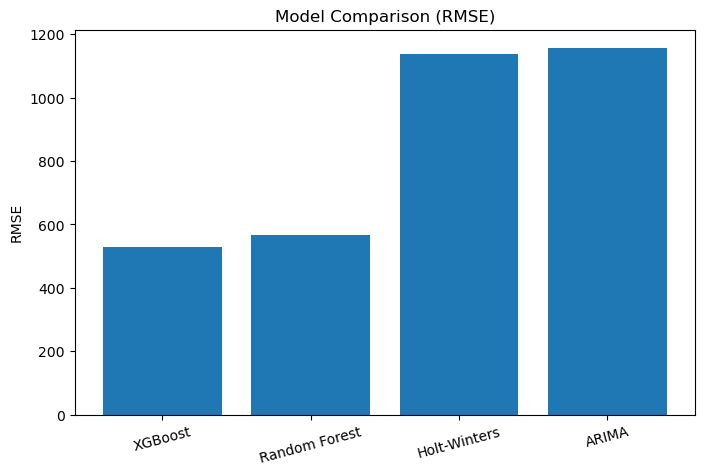

In [227]:
comparison = pd.DataFrame({
    'Model': [
        'Holt-Winters',
        'ARIMA',
        'Random Forest',
        'XGBoost'
    ],
    'RMSE': [
        1136.68,
        arima_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

comparison = comparison.sort_values('RMSE')

plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['RMSE'])
plt.title('Model Comparison (RMSE)')
plt.ylabel('RMSE')
plt.xticks(rotation=15)
plt.show()

# Conclusion

Multiple forecasting techniques were implemented and evaluated on the PJMW electricity demand dataset.

The dataset was cleaned, transformed into a continuous hourly time series, and enhanced using feature engineering techniques including calendar features, seasonal indicators, holiday information, and rolling averages.

The forecasting performance of Holt-Winters, ARIMA, Random Forest, and XGBoost models was evaluated using MAE and RMSE metrics.

Among all models, XGBoost achieved the lowest forecasting error and provided the most accurate predictions. Random Forest also demonstrated strong performance, while Holt-Winters and ARIMA showed comparatively higher forecasting errors.

Therefore, XGBoost was selected as the final recommended model for electricity demand forecasting in this project.

In [228]:
import joblib

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(le_day,    'le_day.pkl')
joblib.dump(le_season, 'le_season.pkl')

print("All 3 saved!")

All 3 saved!
